# Explore Window Level Crafted Features

In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")

from src.metrics.window_metric_dataset import WindowMetricDataset, MILBagDataset
from torch.utils.data import DataLoader, Subset

In [3]:
processed_path = "data/processed"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)[cols_to_keep]
        pbar.update(1)

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:  97%|█████████▋| 83/86 [00:32<00:01,  2.54it/s]


In [32]:
validation_goups = np.random.choice(range(1, 30), size=0, replace=False)
# For current version results:
#validtation_groups = np.array([18, 15,  9, 19, 23, 22])
#[1, 11, 17, 18, 27, 28]
train_groups = [g for g in range(1, 30) if (g not in validation_goups or g==8)]

train_df_dict = {key: df_dict[key] for key in df_dict.keys() if key[1] in train_groups}
val_df_dict = {key: df_dict[key] for key in df_dict.keys() if key[1] in validation_goups}

train_dataset = MILBagDataset(
    df_dict=train_df_dict, 
    grs_scores=grs_scores,
    hand="Right", 
    orig_fps=30.0,
    log_transform=False,
    window_size=60,
    step_size=20
)

val_dataset = MILBagDataset(
    df_dict=val_df_dict, 
    grs_scores=grs_scores,
    hand="Right", 
    orig_fps=30.0,
    scaler=train_dataset.scaler,
    log_transform=False,
    window_size=60,
    step_size=20
)

Generating MIL Bags: 100%|██████████| 83/83 [00:14<00:00,  5.75it/s]
Generating MIL Bags: 0it [00:00, ?it/s]


In [27]:
validation_goups

array([22, 18,  4, 20,  2, 19])

In [28]:
train_dataset[0][0].shape

torch.Size([300, 7])

In [33]:
import numpy as np
import pandas as pd

# collect all feats into a list of 2D arrays
arrays = [feats for feats, _, _ in train_dataset] + \
         [feats for feats, _, _ in val_dataset]

# concatenate along time dimension
# each feats has shape (T_i, C), so this gives (sum(T_i), C)
all_data = np.concatenate(arrays, axis=0)

df_all_data = pd.DataFrame(all_data, columns=["path_length_ratio", "dimensionless_squared_jerk", "mean_curvature", "number_of_reversals", "std_of_velocity_magnitude", "total_path_length", "mean_vel"])

# if you have a "mask" column, filter as needed
df_all_data.describe()

,path_length_ratio,dimensionless_squared_jerk,mean_curvature,number_of_reversals,std_of_velocity_magnitude,total_path_length,mean_vel
count,5.200800e+04,52008.000000,52008.000000,52008.000000,52008.000000,5.200800e+04,5.200800e+04
mean,6.513077e-01,0.655648,0.301798,0.143484,0.488626,3.053815e-01,3.179887e-01
std,1.744040e+00,1.950348,0.891637,0.734710,1.365054,9.714279e-01,1.009579e+00
min,-4.204065e-01,-0.664746,-0.618492,-1.000000,-0.597306,-6.770300e-01,-6.715214e-01
25%,-2.612437e-01,-0.342324,-0.332624,-0.333333,-0.312344,-3.716585e-01,-3.695100e-01
50%,-2.669913e-08,0.000000,0.000000,0.000000,0.000000,3.686000e-08,3.630907e-08
75%,7.387563e-01,0.657676,0.667376,0.666667,0.687656,6.283415e-01,6.304900e-01
max,1.000000e+01,10.000000,8.313045,3.666667,10.000000,9.563850e+00,1.000000e+01


In [30]:
import torch
def mil_collate_fn(batch):
    """
    Collate function to handle variable-sized bags.
    Returns:
        bags: List of (N, 5) tensors
        labels: Tensor of shape (Batch_Size, 1)
        ids: List of identifiers
    """
    bags, labels, ids = zip(*batch)
    labels = torch.stack(labels) # Stack to (B, 1)
    return list(bags), labels, ids

In [31]:
train_loader = DataLoader(train_dataset, batch_size=13, shuffle=True, collate_fn=mil_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=mil_collate_fn)

# Attention MIL Training

In [32]:
from src.models.attention_mil import run_training
    
model, history = run_training(
    train_loader=train_loader,
    val_loader=val_loader,
    input_dim=7,
    epochs=4000,
    lr=3e-4,
)

Starting training on cpu for 4000 epochs...
Epoch | Train Loss | Val Loss   | Val MAE    | Spearman  
-----------------------------------------------------------------


1     | 67.3911     | 109.9796     | 9.5036     | 0.0516
2     | 90.8249     | 110.8588     | 9.5418     | 0.0540
3     | 96.0550     | 111.8033     | 9.5872     | 0.0540
4     | 70.5490     | 112.8819     | 9.6452     | 0.0847
5     | 66.2214     | 113.7057     | 9.6891     | 0.0847
6     | 80.4447     | 114.2779     | 9.7197     | 0.0847
7     | 65.7222     | 114.8615     | 9.7504     | 0.0847
8     | 65.8712     | 115.2839     | 9.7729     | 0.1056
9     | 66.1345     | 115.5596     | 9.7885     | 0.1056
10    | 65.5823     | 115.7024     | 9.7973     | 0.1056
11    | 109.5727     | 115.7691     | 9.8026     | 0.1056
12    | 66.3462     | 115.4137     | 9.7880     | 0.1056
13    | 74.0188     | 115.3445     | 9.7870     | 0.1265
14    | 65.3981     | 115.2444     | 9.7842     | 0.1265
15    | 65.6809     | 115.2080     | 9.7846     | 0.1265
16    | 65.5095     | 115.0614     | 9.7793     | 0.1265
17    | 73.4787     | 115.0124     | 9.7787     | 0.1265
18    | 65.1662     | 115.2521

KeyboardInterrupt: 

In [11]:
val_df_dict.keys()

dict_keys([('2024-01-18_14-39-24', 11), ('2024-01-18_15-17-27', 11), ('2024-01-17_16-22-28', 7), ('2024-01-18_14-55-56', 11), ('2024-01-17_16-04-01', 7), ('2024-01-24_14-44-22', 27), ('2024-01-22_13-54-13', 17), ('2024-01-22_13-18-56', 17), ('2024-01-24_15-06-52', 27), ('2024-01-15_15-38-13', 2), ('2024-01-23_08-43-31', 21), ('2024-01-23_08-23-33', 21), ('2024-01-24_14-26-36', 27), ('2024-01-23_08-09-57', 21), ('2024-01-15_15-05-31', 2), ('2024-01-17_16-48-38', 7), ('2024-01-15_14-32-45', 2), ('2024-01-22_13-34-51', 17)])

In [ ]:
('2024-01-18_14-39-24', 11) : 47.0

In [ ]:
from src.models.attention_mil import validate
import torch.nn as nn

validate(model, val_loader, nn.MSELoss(), "cpu")


{'val_loss': 53.72433470396532,
 'mae': np.float64(6.450456619262695),
 'pearson': np.float64(0.6941123200691751),
 'spearman': np.float64(0.6181630546955624)}

# BoW feature generation using the window features

In [5]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import RobustScaler
from tqdm import tqdm # Assuming tqdm is available for progress tracking

# --- 1. SETUP: Replace with your actual data and scaling process ---

# Assuming this list contains all N_total x 6 feature vectors, scaled and clipped
# This is equivalent to your all_window_features_flat *after* scaling/clipping
# You will likely extract this from your MILBagDataset object's internal structure.
# Example: all_window_features_flat_scaled = np.concatenate(self.bags) 

# Assuming you already have:
# all_window_features_flat_scaled: (N_total, D) array of all window features (D=6 in your case), already scaled/clipped
# self.bags: A list of numpy arrays, where each array is (N_i, D) for video i
# self.bag_ids: A list of identifiers for each video (e.g., [('Video1', 'S1'), ('Video2', 'S2'), ...])

# --- 2. Hyperparameters ---
K_CLUSTERS = 50  # Start between 20 and 50. K=30 is a good default.
RANDOM_SEED = 40
N_INIT = 3 # Number of times to initialize K-Means

def generate_bow_features(all_window_features_flat_scaled, bags_list, bag_ids):
    """
    Applies K-Means clustering to all windows (the vocabulary) and then
    creates a histogram (BoW vector) for each video (bag).

    Args:
        all_window_features_flat_scaled (np.ndarray): (N_total, D) array of all scaled window features.
        bags_list (list): List of (N_i, D) np.ndarrays for each video.
        bag_ids (list): List of video identifiers.

    Returns:
        pd.DataFrame: A DataFrame where rows are videos and columns are BoW cluster counts.
    """
    
    # --- Step A: Train the K-Means Model (The Vocabulary) ---
    print(f"Fitting K-Means model with K={K_CLUSTERS}...")
    
    # Use MiniBatchKMeans for potentially faster training on large window sets
    kmeans = MiniBatchKMeans(
        n_clusters=K_CLUSTERS,
        init='k-means++',
        n_init=N_INIT,
        random_state=RANDOM_SEED,
        # Set max_iter higher if convergence is an issue
    )
    
    kmeans.fit(all_window_features_flat_scaled)

    all_cluster_assignments = kmeans.predict(all_window_features_flat_scaled)
    
    print("K-Means fit complete. Generating histograms...")

    # --- Step B: Generate Histograms (The BoW Feature Vectors) ---
    bow_features = []

    for bag_array, bag_id in tqdm(zip(bags_list, bag_ids), total=len(bags_list), desc="Generating BoW Histograms"):
        
        # 1. Quantization: Predict the cluster for every window in the current bag
        # Output is (N_i,) array of cluster indices (0 to K-1)
        cluster_assignments = kmeans.predict(bag_array)
        
        # 2. Histogram: Count the frequency of each cluster index
        # The result is the BoW feature vector for this video
        histogram, _ = np.histogram(
            cluster_assignments,
            bins=np.arange(K_CLUSTERS + 1), # Bins from 0 up to K_CLUSTERS
            density=False # Count, not probability
        )
        
        # Normalize the histogram by the number of windows in the video
        # This makes the feature robust to differences in video length
        total_windows = len(bag_array)
        bow_vector = histogram / (total_windows + 1e-6) # Use a small constant for safety
        
        bow_features.append(bow_vector)

    # Create column names (e.g., 'BoW_0', 'BoW_1', ...)
    col_names = [f'BoW_{i}' for i in range(K_CLUSTERS)]
    
    bow_df = pd.DataFrame(bow_features, columns=col_names, index=pd.MultiIndex.from_tuples(bag_ids, names=['VideoName', 'SurgeonID']))
    
    print("BoW feature generation complete.")
    return bow_df, all_cluster_assignments, kmeans

# Example Usage (You will integrate this into your existing pipeline):
# 1. Get the scaled data: 
#    If using your MILBagDataset, you will need to aggregate the scaled bags:
#    all_window_features_flat_scaled = np.concatenate([bag.cpu().numpy() for bag, _, _ in dataset]) 
#    bags_list = [bag.cpu().numpy() for bag, _, _ in dataset]
#    bag_ids = [bag_id for _, _, bag_id in dataset]

# 2. Run the function:
# bow_df = generate_bow_features(all_window_features_flat_scaled, bags_list, bag_ids)
# print(bow_df.head())

# 3. Hybrid Regression:
# X_global = your_global_pca_features_df
# X_hybrid = pd.concat([X_global, bow_df], axis=1)
# Train your LMM/XGBoost on X_hybrid


import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.decomposition import PCA # PCA for t-SNE initialization

def visualize_cluster_assignment(
    all_window_features_flat_scaled, 
    all_cluster_assignments, 
    K_CLUSTERS=None, 
    method='UMAP', 
    N_SAMPLES=5000,
    is_discrete=True
):
    """
    Applies either t-SNE or UMAP to the window features, coloring points by their K-Means 
    cluster assignment to validate the clustering quality.

    Args:
        all_window_features_flat_scaled (np.ndarray): (N_total, D) array of all scaled window features.
        all_cluster_assignments (np.ndarray): (N_total,) array of cluster indices (0 to K-1).
        K_CLUSTERS (int): The total number of clusters used in K-Means.
        method (str): Choose 'UMAP' or 'TSNE'. Defaults to 'UMAP'.
        N_SAMPLES (int): Number of random samples to plot (recommended for large N_total).
    """
    method = method.upper()
    if method not in ['UMAP', 'TSNE']:
        raise ValueError("Method must be 'UMAP' or 'TSNE'.")

    N_total = all_window_features_flat_scaled.shape[0]
    
    if N_total == 0:
        print("Error: Input features array is empty.")
        return

    # --- 1. Sampling for Performance ---
    if N_total > N_SAMPLES:
        print(f"Dataset size ({N_total}) is large. Sampling {N_SAMPLES} points for visualization...")
        
        rng = np.random.default_rng(seed=42)
        sample_indices = rng.choice(N_total, N_SAMPLES, replace=False)
        
        X_sample = all_window_features_flat_scaled[sample_indices]
        Y_sample = all_cluster_assignments[sample_indices]
    else:
        print(f"Using all {N_total} points for visualization.")
        X_sample = all_window_features_flat_scaled
        Y_sample = all_cluster_assignments

    # Convert to DataFrame for easier handling and plotting metadata
    df_sample = pd.DataFrame(X_sample)
    df_sample['Cluster_ID'] = Y_sample
    df_sample['Cluster_ID'] = df_sample['Cluster_ID'].astype('category')
    
    # --- 2. Dimensionality Reduction ---
    
    print(f"Computing {method} embeddings (this may take a few moments)...")
    
    if method == 'UMAP':
        reducer = umap.UMAP(
            n_neighbors=15, 
            min_dist=0.1, 
            n_components=2, 
            random_state=42
        )
        # Using tqdm for progress tracking during the fit_transform
        # UMAP can be slow, so we provide some feedback
        with tqdm(total=100, desc="UMAP Progress", unit="iter") as pbar:
            embedding = reducer.fit_transform(df_sample.drop(columns=['Cluster_ID']))
            pbar.update(100) # Simple completion flag
        title = f'UMAP of Window Features (N={len(df_sample)})'

    elif method == 'TSNE':
        # Apply PCA first for initialization, which is standard practice for t-SNE
        # and helps with convergence speed/quality, especially with higher dimensional inputs.
        pca_dim = min(50, X_sample.shape[1]) 
        X_pca = PCA(n_components=pca_dim, random_state=42).fit_transform(X_sample)
        
        tsne = TSNE(
            n_components=2, 
            learning_rate='auto', 
            init='pca', 
            perplexity=30, # Adjust perplexity (often 5 to 50)
            random_state=42, 
            n_jobs=-1
        )
        embedding = tsne.fit_transform(X_pca)
        title = f't-SNE of Window Features (N={len(df_sample)})'

    df_sample['X'] = embedding[:, 0]
    df_sample['Y'] = embedding[:, 1]
    
        # --- 3. Plotting ---
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    color_vals = df_sample['Cluster_ID'].values

    if is_discrete:
        # ----- DISCRETE CASE (clusters) -----
        unique_vals = np.unique(color_vals)
        num_vals = len(unique_vals)

        # Map values to range 0..num_vals-1 for consistent coloring
        value_to_index = {v: i for i, v in enumerate(unique_vals)}
        mapped = np.vectorize(value_to_index.get)(color_vals)

        cmap = plt.cm.get_cmap("tab20", num_vals)
        scatter = ax.scatter(
            df_sample['X'], df_sample['Y'],
            c=mapped,
            cmap=cmap,
            marker='.',
            alpha=0.8
        )

        # Discrete colorbar
        cbar = fig.colorbar(
            scatter, ax=ax, ticks=np.arange(num_vals)
        )
        cbar.set_ticklabels(unique_vals)
        cbar.set_label("Cluster ID")

    else:
        # ----- CONTINUOUS CASE (scores) -----
        scatter = ax.scatter(
            df_sample['X'], df_sample['Y'],
            c=color_vals,
            cmap="viridis",
            marker='.',
            alpha=0.8
        )
        # Continuous colorbar
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label("Score")

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(f'{method} Dimension 1')
    ax.set_ylabel(f'{method} Dimension 2')

    plt.tight_layout()
    plt.show()


In [34]:
# get scaled data
all_window_features_flat_scaled = np.concatenate([bag.cpu().numpy() for bag, _, _ in train_dataset] + [bag.cpu().numpy() for bag, _, _ in val_dataset])
bag_list = [bag.cpu().numpy() for bag, _, _ in train_dataset] + [bag.cpu().numpy() for bag, _, _ in val_dataset]
bag_ids = [bag_id for _, _, bag_id in train_dataset] + [bag_id for _, _, bag_id in val_dataset]
bag_scores = [score for _, score, _ in train_dataset] + [score for _, score, _ in val_dataset]

# run K means and get BoW features
bow_df, all_cluster_assignments, kmeans = generate_bow_features(all_window_features_flat_scaled, bag_list, bag_ids)

Fitting K-Means model with K=50...
K-Means fit complete. Generating histograms...


Generating BoW Histograms: 100%|██████████| 83/83 [00:00<00:00, 1809.57it/s]

BoW feature generation complete.


## First check that the k-means clustering worked at window level

- Cluster feature means inspection (TO DO)
- UMAP of window features with their assigned cluser as clor label (Done) => looks like it worked quite well

Dataset size (33889) is large. Sampling 2000 points for visualization...
Computing UMAP embeddings (this may take a few moments)...


UMAP Progress:   0%|          | 0/100 [00:00<?, ?iter/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
UMAP Progress: 100%|██████████| 100/100 [00:14<00:00,  6.97iter/s]
/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_99203/3554251116.py:212: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_vals)


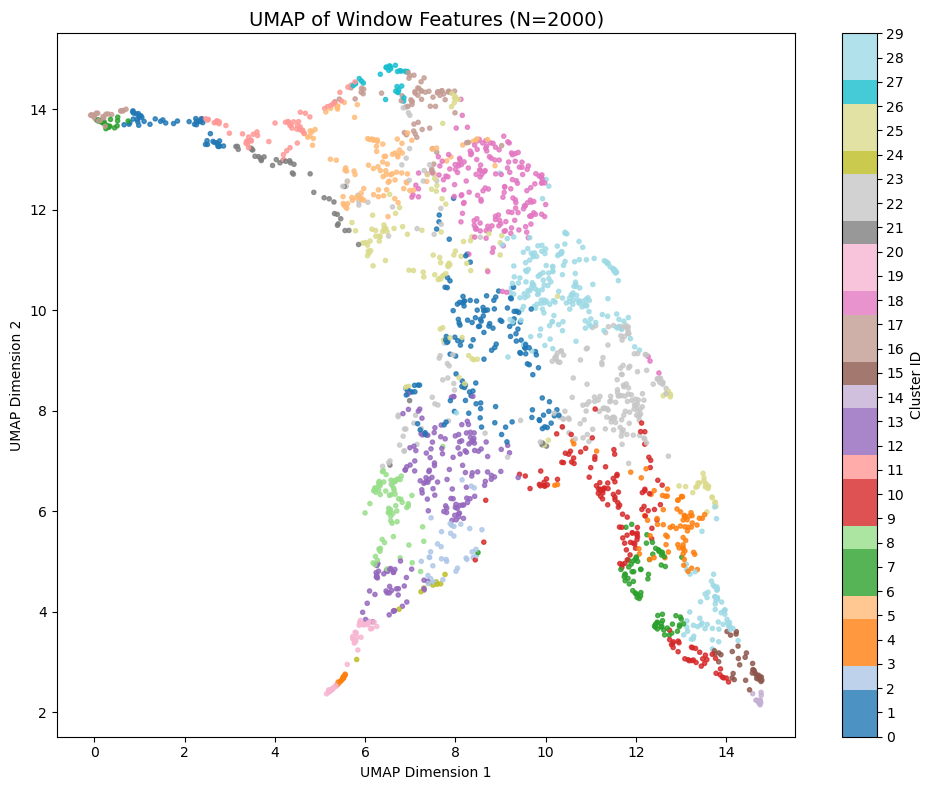

In [35]:
visualize_cluster_assignment(all_window_features_flat_scaled, all_cluster_assignments, K_CLUSTERS=K_CLUSTERS, N_SAMPLES=2000)

## UMAP of BoW Features

!! Doesn't look very promissing !!

Using all 83 points for visualization.
Computing UMAP embeddings (this may take a few moments)...


UMAP Progress:   0%|          | 0/100 [00:00<?, ?iter/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP Progress: 100%|██████████| 100/100 [00:00<00:00, 635.62iter/s]


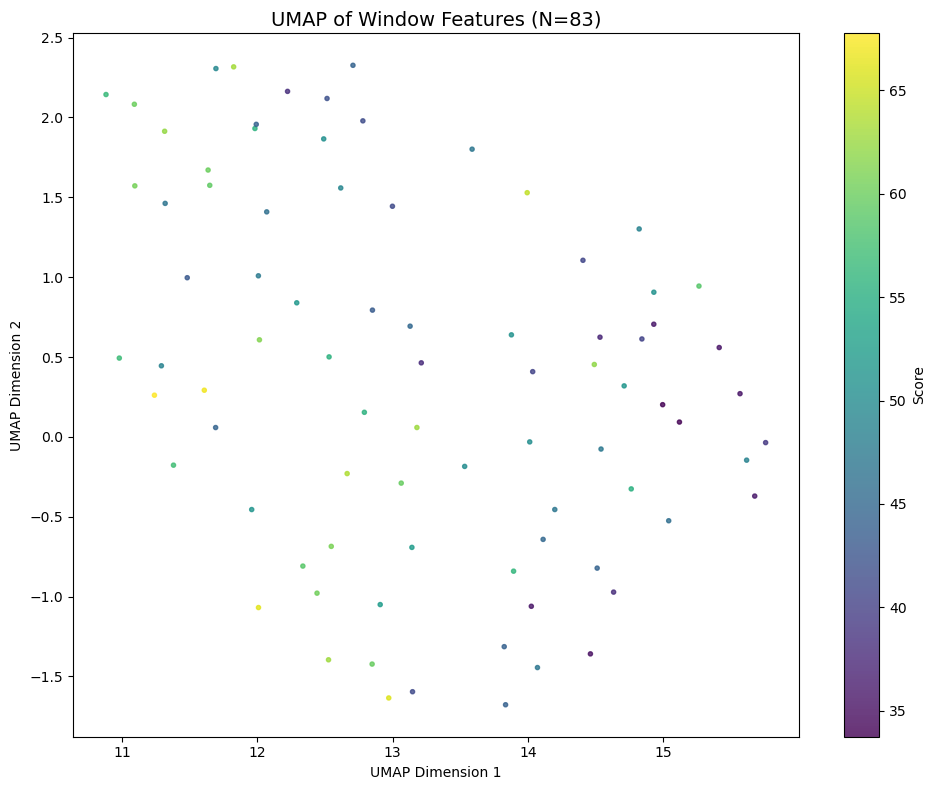

In [35]:
#bow_df = bow_df.sort_index()
X_bow = bow_df.values

visualize_cluster_assignment(X_bow, np.array(bag_scores).flatten(), is_discrete=False)

# Let's have a closer look at the individual BoW features

In [36]:
# standardize the data using standard scaler
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr

scaler = StandardScaler()
X_bow_scaled = scaler.fit_transform(X_bow)

scaled_bow_df = pd.DataFrame(X_bow_scaled, columns=bow_df.columns, index=bow_df.index)
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
pearson_corrs = []
spearman_corrs = []
for i in range(X_bow_scaled.shape[1]):
    pearson_corr, _ = pearsonr(X_bow_scaled[:, i], np.array(bag_scores).flatten())
    spearman_corr, _ = spearmanr(X_bow_scaled[:, i], np.array(bag_scores).flatten())
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 10 BoW features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:12]
for idx in top_pearson_indices:
    print(f"BoW_{idx}: Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 10 BoW features by Pearson correlation:
BoW_36: Pearson r = 0.4530, Spearman rho = 0.4151
BoW_37: Pearson r = -0.4218, Spearman rho = -0.4145
BoW_4: Pearson r = 0.4113, Spearman rho = 0.4132
BoW_0: Pearson r = -0.4032, Spearman rho = -0.3866
BoW_48: Pearson r = 0.3840, Spearman rho = 0.3294
BoW_3: Pearson r = 0.3827, Spearman rho = 0.3906
BoW_15: Pearson r = -0.3814, Spearman rho = -0.3672
BoW_25: Pearson r = -0.3803, Spearman rho = -0.3523
BoW_27: Pearson r = -0.3271, Spearman rho = -0.3119
BoW_46: Pearson r = 0.3253, Spearman rho = 0.3661
BoW_47: Pearson r = -0.3093, Spearman rho = -0.4004
BoW_21: Pearson r = 0.3058, Spearman rho = 0.3566


In [23]:
top_pearson_indices[:5]

array([41,  2, 10, 17, 12])

Using all 83 points for visualization.
Computing UMAP embeddings (this may take a few moments)...


UMAP Progress:   0%|          | 0/100 [00:00<?, ?iter/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP Progress: 100%|██████████| 100/100 [00:00<00:00, 442.86iter/s]


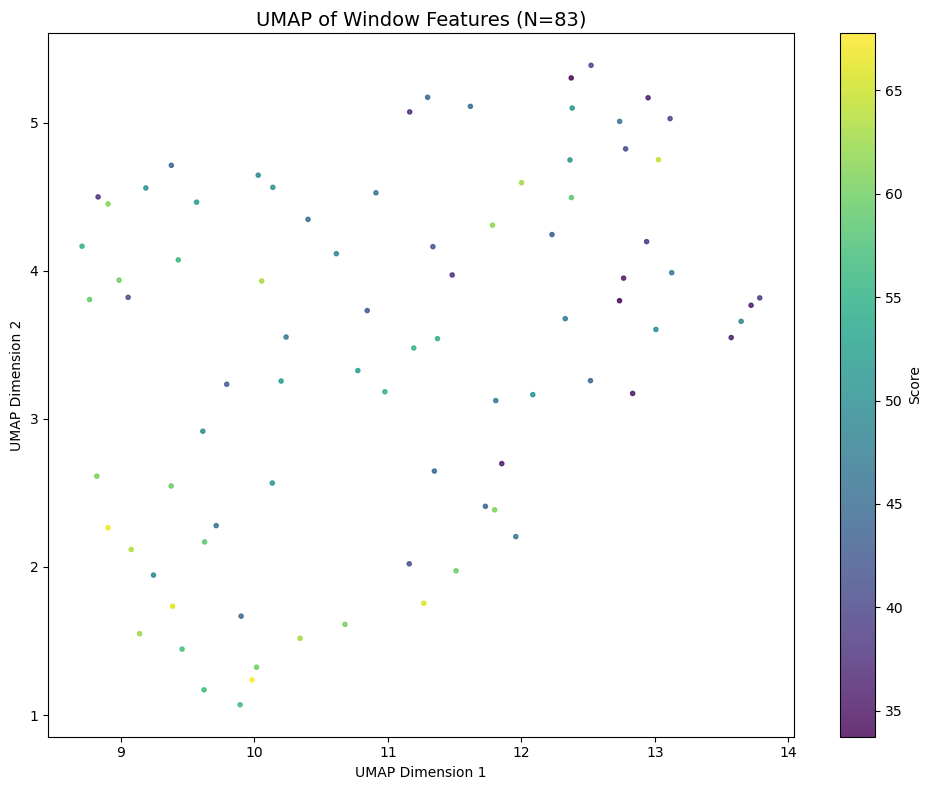

In [37]:
X_bow_filtered = X_bow[:, top_pearson_indices[:5]]
visualize_cluster_assignment(X_bow_filtered, np.array(bag_scores).flatten(), is_discrete=False)

In [38]:
# check cluster centroids for top positive and negative predictors

centroids = kmeans.cluster_centers_
feature_names = ['PathRatio', 'Jerk', 'Curvature', 'Reversals', 'StdVel', 'TotalPath', 'MeanVel']

print("--- Negative Predictors (Novice Moves) ---")
for idx in [37, 0]:
    print(f"Cluster {idx}: {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

print("\n--- Positive Predictors (Expert Moves) ---")
for idx in [36, 4]:
    print(f"Cluster {idx}: {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

--- Negative Predictors (Novice Moves) ---
Cluster 37: {'PathRatio': np.float32(0.05), 'Jerk': np.float32(-0.28), 'Curvature': np.float32(-0.31), 'Reversals': np.float32(0.15), 'StdVel': np.float32(0.41), 'TotalPath': np.float32(0.46), 'MeanVel': np.float32(0.46)}
Cluster 0: {'PathRatio': np.float32(-0.05), 'Jerk': np.float32(-0.04), 'Curvature': np.float32(0.06), 'Reversals': np.float32(0.59), 'StdVel': np.float32(-0.15), 'TotalPath': np.float32(-0.2), 'MeanVel': np.float32(-0.2)}

--- Positive Predictors (Expert Moves) ---
Cluster 36: {'PathRatio': np.float32(1.91), 'Jerk': np.float32(0.09), 'Curvature': np.float32(-0.11), 'Reversals': np.float32(0.89), 'StdVel': np.float32(-0.02), 'TotalPath': np.float32(0.1), 'MeanVel': np.float32(0.09)}
Cluster 4: {'PathRatio': np.float32(4.75), 'Jerk': np.float32(0.31), 'Curvature': np.float32(-0.06), 'Reversals': np.float32(0.72), 'StdVel': np.float32(0.21), 'TotalPath': np.float32(0.4), 'MeanVel': np.float32(0.39)}


# Hybrid Model : Combine top BoW features with global PCA features

In [26]:
# load 
df_metrics = pd.read_csv("data/metrics/best_global_metrics2.csv")
df_metrics.head()

,Participant Number,GRS_Total,QRS_Overal,Case_Number,adjusted_total_path_Right,total_duration_Right,num_reversals_Right,velocity_corr,interhand_dist_change_rms,mean_abs_angle_change_Right
0,1,59.25,48.50,1,62034.389107,534.933333,737,0.300569,37.862266,0.726575
1,1,54.40,45.00,2,37353.044239,288.033333,378,0.642479,37.941429,0.899482
2,1,74.50,60.50,3,51364.691660,423.033333,694,0.476772,39.133227,0.929110
3,2,49.25,39.25,1,103592.752300,1281.533333,1571,0.356040,23.805603,0.726725
4,2,49.00,38.00,2,74343.087367,1010.833333,1133,0.475344,21.928832,0.714639


In [27]:
bow_df = bow_df.sort_index()
bow_df.reset_index(['VideoName', 'SurgeonID'], inplace=True)
df_combined = pd.merge(bow_df, df_metrics, left_index=True, right_index=True)

In [28]:
all(df_combined['Participant Number'] == df_combined['SurgeonID'])


True

In [29]:
# leakage free version:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from tqdm import tqdm
from sklearn.linear_model import Ridge, RidgeCV

def leakage_free_residual_analysis(
    df,
    candidate_features,
    target='QRS_Overal',
    surgeon_col='Participant Number',
    pcs_to_use=[0, 1, 2],
    pca_features=['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']
):
    """
    Evaluates candidate features by identifying their contribution to residuals
    using a Leave-One-Surgeon-Out cross-validation approach.
    """
    unique_surgeons = df[surgeon_col].unique()
    fold_results = []

    for surgeon_out in tqdm(unique_surgeons, desc="Analyzing Folds"):
        # Split Data
        df_train = df[df[surgeon_col] != surgeon_out].dropna(subset=[target] + candidate_features + pca_features).copy()
        
        # 1. Baseline PCA & Model (Fit on Train ONLY)
        scaler = StandardScaler()
        X_train_pca_raw = scaler.fit_transform(df_train[pca_features])
        
        pca = PCA(n_components=max(pcs_to_use) + 1)
        train_pcs = pca.fit_transform(X_train_pca_raw)
        
        # Define baseline columns
        pc_cols = [f'PC{i+1}' for i in range(train_pcs.shape[1])]
        df_train[pc_cols] = train_pcs
        used_pc_cols = [pc_cols[i] for i in pcs_to_use]
        
        # 2. Baseline Model (Train residuals)
        y_train = df_train[target].values
        pc_model = Ridge(alpha=0.5)
        pc_model.fit(df_train[used_pc_cols], y_train)
        
        train_residuals = y_train - pc_model.predict(df_train[used_pc_cols])
        pc_resid_var = np.var(train_residuals)

        # 3. Evaluate Candidate Features on this Fold
        for feat in candidate_features:
            # Partial R2 calculation on train set
            X_full = df_train[used_pc_cols + [feat]]
            full_model = Ridge(alpha=0.5)
            full_model.fit(X_full, y_train)
            
            full_resid_var = np.var(y_train - full_model.predict(X_full))
            partial_r2 = 1 - (full_resid_var / pc_resid_var)
            
            # Correlation with residuals
            r, _ = pearsonr(df_train[feat], train_residuals)
            
            fold_results.append({
                'Fold_Surgeon_Out': surgeon_out,
                'Feature': feat,
                'Partial_R2': partial_r2,
                'Resid_Corr': r
            })

    # ==============================
    # 4. Aggregate Results across all folds
    # ==============================
    results_df = pd.DataFrame(fold_results)
    
    # We want to know:
    # 1. Mean Partial R2
    # 2. Selection Frequency (how often is it in the top 10?)
    summary = results_df.groupby('Feature').agg({
        'Partial_R2': ['mean', 'std'],
        'Resid_Corr': ['mean', 'std']
    }).reset_index()
    
    summary.columns = ['Feature', 'Mean_Partial_R2', 'Std_Partial_R2', 'Mean_Resid_Corr', 'Std_Resid_Corr']

    results_df['Resid_Corr'] = results_df['Resid_Corr'].abs()
    
    # Calculate "Stability": How often was this feature in the top 10 of its fold?
    results_df['Rank'] = results_df.groupby('Fold_Surgeon_Out')['Resid_Corr'].rank(ascending=False)
    stability = results_df[results_df['Rank'] <= 1]['Feature'].value_counts() / len(unique_surgeons)
    stability = stability.rename('Selection_Stability').reset_index().rename(columns={'index': 'Feature'})
    
    final_summary = summary.merge(stability, on='Feature', how='left').fillna(0)
    
    return final_summary.sort_values('Mean_Partial_R2', ascending=False)

# Usage:

df_res_leakage_free = leakage_free_residual_analysis(df_combined, [col for col in df_combined.columns if col.startswith('BoW_')])
df_res_leakage_free

Analyzing Folds: 100%|██████████| 28/28 [00:06<00:00,  4.62it/s]


,Feature,Mean_Partial_R2,Std_Partial_R2,Mean_Resid_Corr,Std_Resid_Corr,Selection_Stability
27,BoW_33,0.006673,0.001219,0.216325,0.020855,0.035714
20,BoW_27,0.005601,0.000874,-0.208122,0.016450,0.000000
9,BoW_17,0.005378,0.000975,0.253387,0.018513,0.035714
47,BoW_7,0.003147,0.000855,0.171667,0.024059,0.000000
36,BoW_41,0.003078,0.000516,-0.209704,0.018301,0.000000
48,BoW_8,0.002315,0.000374,0.218424,0.016437,0.000000
6,BoW_14,0.002274,0.000412,-0.240206,0.022321,0.000000
18,BoW_25,0.002198,0.000624,-0.168282,0.024424,0.000000
3,BoW_11,0.002162,0.000633,-0.137616,0.019380,0.000000
12,BoW_2,0.002133,0.000456,0.234932,0.023995,0.035714


Starting Leave-One-Surgeon-Out CV with 28 folds...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 127.53it/s]



          HYBRID MODEL (RIDGE) LOSOCV RESULTS
Overall Correlation (R): 0.7675
Overall MAE: 4.8903
Overall Std Dev of Errors: 3.4270

--- Per-Fold Performance Summary ---
           Train_MAE  Test_MAE  Test_Corr
SurgeonID                                
1           4.405972  6.601852  -0.654426
2           4.522562  2.978862   0.813838
3           4.360307  9.831490   0.819432
4           4.485444  5.073867  -0.253569
5           4.407188  7.793268   0.713638
6           4.594365  1.981168   0.812221
7           4.351954  8.029710  -0.620289
9           4.408750  6.961824  -0.844562
10          4.481616  4.805883   0.993000
11          4.530502  3.437586   0.163183
12          4.514139  3.846996  -0.490804
13          4.535457  3.672243   0.880932
14          4.520593  3.682401  -0.687681
15          4.554557  2.580370   0.933599
16          4.342771  8.660024  -0.138524
17          4.608465  1.264057   0.996998
18          4.443586  5.885279   0.960950
19          4.478092  4.794142 

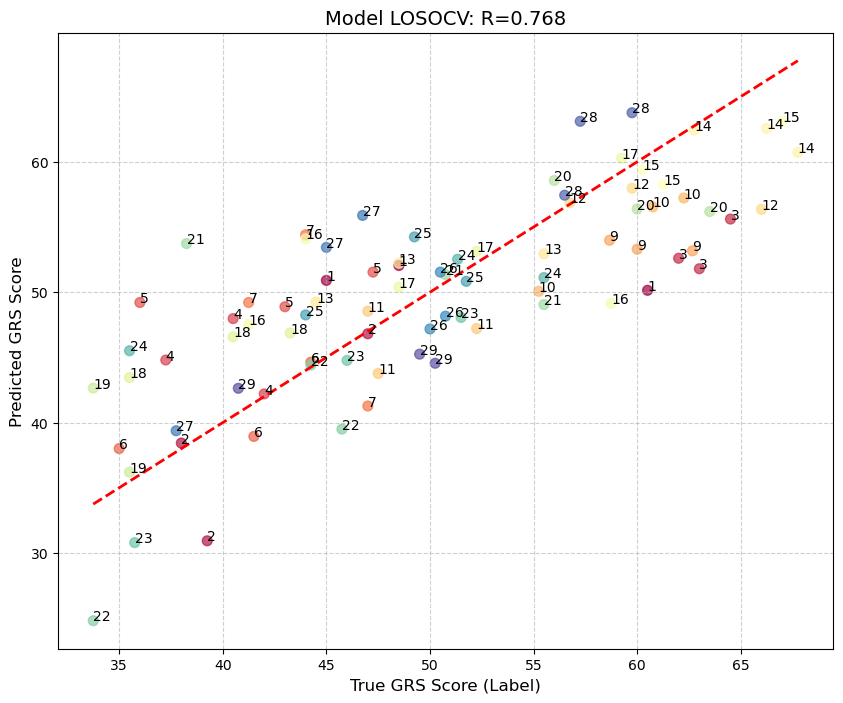

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Prepare Data (Code adapted from your input) ---

# --- IMPORTANT ASSUMPTIONS ---
# 1. merged_feature_df is available and c§orrectly indexed.
# 2. 'QRS_Overal' is the column for the true scores (y).
# 3. 'Participant Number' is the column for SurgeonID.
# 4. Feature columns are PC1, PC2, PC3, BoW_2, BoW_20.
# ------------------------------

feature_cols = [col for col in ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']]#, 'velocity_corr']]
additional_feature_cols = ['BoW_17'] #['mean_abs_angle_change_Right']#['Rocket_PC27', 'Rocket_PC7', 'Rocket_PC19', 'Rocket_PC5', 'Rocket_PC24', 'Rocket_PC40']  # 'Rocket_PC25', 'Rocket_PC21', 'Rocket_PC22'
all_feature_cols = feature_cols + additional_feature_cols
X = df_combined[all_feature_cols].values
y = df_combined['QRS_Overal'].values

# Extract the Surgeon IDs for the folds
surgeon_ids = df_combined['Participant Number'].values # Assuming 'Participant Number' holds the unique surgeon/participant identifier

unique_surgeons = np.unique(surgeon_ids)
predictions = []
true_scores = []
fold_results = {} # To store results per fold

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with {len(unique_surgeons)} folds...")

# We will collect fold-level predictions for plotting
all_fold_preds = []
all_fold_true = []
all_fold_surgeons = []


for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    # Define Folds
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # PCA but only on feature_cols
    pca = PCA(n_components=min(3, len(feature_cols)))  # Adjust number of components as needed
    X_train_pca = pca.fit_transform(X_train[:, :len(feature_cols)])
    X_test_pca = pca.transform(X_test[:, :len(feature_cols)])
    
    # component list to keep
    component_list = [0,1,2]  # Keep only the first principal component
    X_train_pca = X_train_pca[:, component_list]
    X_test_pca = X_test_pca[:, component_list]
    
    # Combine PCA features with additional features
    X_train = np.hstack((X_train_pca, X_train[:, len(feature_cols):]))
    X_test = np.hstack((X_test_pca, X_test[:, len(feature_cols):]))

    # 3. Train Model
    # Using the optimized alpha=0.5
    model = Ridge(alpha=0.5)                    # RidgeCV(alphas=np.logspace(-2, 4, 20)). TO CHANGE LATER
    model.fit(X_train, y_train)
    
    # Predict and store
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate Fold Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_corr, _ = pearsonr(y_test, y_test_pred)
    
    fold_results[surgeon_out] = {
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Test_Corr': test_corr
    }
    
    # Store results for overall metrics and plotting
    predictions.extend(y_test_pred)
    true_scores.extend(y_test)
    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 4. Evaluate and Print Results ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = spearmanr(final_true_scores, final_predictions)

# Create a DataFrame for per-fold results
fold_results_df = pd.DataFrame.from_dict(fold_results, orient='index')
fold_results_df.index.name = 'SurgeonID'

print("\n=================================================")
print("          HYBRID MODEL (RIDGE) LOSOCV RESULTS")
print("=================================================")
print(f"Overall Correlation (R): {hybrid_corr:.4f}")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"\n--- Per-Fold Performance Summary ---")
print(fold_results_df)

# --- 5. Visualization ---
plt.figure(figsize=(10, 8))

# Scatter plot
scatter = plt.scatter(
    all_fold_true, 
    all_fold_preds, 
    c=all_fold_surgeons, # Color by surgeon ID
    cmap='Spectral', 
    label='Predicted Scores',
    s=50,
    alpha=0.7
)

for i, sid in enumerate(surgeon_ids):
    plt.annotate(f'{sid}', (all_fold_true[i], all_fold_preds[i]))

# Diagonal Line (Perfect prediction)
plt.plot(
    [min(final_true_scores), max(final_true_scores)], 
    [min(final_true_scores), max(final_true_scores)], 
    'r--', 
    lw=2,
    label='Ideal Prediction (y=x)'
)

plt.xlabel("True GRS Score (Label)", fontsize=12)
plt.ylabel("Predicted GRS Score", fontsize=12)
plt.title(f"Model LOSOCV: R={hybrid_corr:.3f}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Check a BoW feature only model performs

In [104]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.ensemble import RandomForestRegressor

# --- 1. Prepare Data (BoW Only) ---
bow_cols = [col for col in df_combined.columns if col.startswith('BoW_')]
X_bow = df_combined[bow_cols].values
y = df_combined['QRS_Overal'].values
surgeon_ids = df_combined['Participant Number'].values 

unique_surgeons = np.unique(surgeon_ids)
all_fold_preds = []
all_fold_true = []
fold_selected_features = []

print(f"Starting BoW-Only RFE LOSOCV...")

for surgeon_out in tqdm(unique_surgeons, desc="RFE Folds"):
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X_bow[train_indices], X_bow[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 2. RFE Selection
    # We use a simple Ridge as the 'ranker' to determine importance
    # We ask RFE to find the best 10 features (adjust as needed)
    estimator = Ridge(alpha=0.5)
    selector = RFE(estimator, n_features_to_select=7, step=1)
    selector = selector.fit(X_train_scaled, y_train)
    
    # 3. Final Prediction with selected BoWs
    # We use RidgeCV on the reduced feature set for better generalization
    X_train_sel = X_train_scaled[:, selector.support_]
    X_test_sel = X_test_scaled[:, selector.support_]
    
    final_model = RidgeCV(alphas=np.logspace(-2, 4, 10))
    final_model.fit(X_train_sel, y_train)
    
    y_test_pred = final_model.predict(X_test_sel)

    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    
    # Track which BoWs were chosen in this fold
    selected_names = [bow_cols[i] for i in np.where(selector.support_)[0]]
    fold_selected_features.extend(selected_names)

# --- 4. Evaluate Standalone BoW Performance ---
final_predictions = np.array(all_fold_preds)
final_true_scores = np.array(all_fold_true)

standalone_mae = mean_absolute_error(final_true_scores, final_predictions)
standalone_corr, _ = spearmanr(final_true_scores, final_predictions)

print("\n=================================================")
print("        STANDALONE BoW RESULTS (RFE)")
print("=================================================")
print(f"Spearman Rho: {standalone_corr:.4f}")
print(f"Overall MAE:  {standalone_mae:.4f}")

# Check which BoW clusters are 'universal' experts/novice signals
feature_counts = pd.Series(fold_selected_features).value_counts()
print("\n--- Most Stable Local Features (Chosen in most folds) ---")
print(feature_counts.head(20))

Starting BoW-Only RFE LOSOCV...


RFE Folds:   0%|          | 0/28 [00:00<?, ?it/s]

RFE Folds: 100%|██████████| 28/28 [00:01<00:00, 15.01it/s]


        STANDALONE BoW RESULTS (RFE)
Spearman Rho: 0.4735
Overall MAE:  6.9060

--- Most Stable Local Features (Chosen in most folds) ---
BoW_30    28
BoW_18    26
BoW_35    25
BoW_26    24
BoW_21    24
BoW_49    24
BoW_41    24
BoW_46     8
BoW_45     3
BoW_0      2
BoW_12     2
BoW_9      1
BoW_20     1
BoW_10     1
BoW_15     1
BoW_28     1
BoW_33     1
Name: count, dtype: int64
